In [49]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from brokenaxes import brokenaxes
import matplotlib.patches as patches
from matplotlib.lines import Line2D

In [50]:
fig_length = {1 : 3.50394,    # 1 column
              1.5 : 5.35433, # 1.5 columns
              2 : 7.20472}    # 2 columns
fig_height = 9.72441 # maximum height
fontsize_title = 9
fontsize_label = 8
fontsize_legend = 8
fontsize_axs = 8

plt.rcParams["figure.autolayout"] = True
plt.rcParams.update({'font.size' : 8})
plt.rcParams['font.family'] = 'Arial'

In [51]:
subdirectories = ['Hydrogen', 'Carbon dioxide', 'Ammonia', 'Methanol', 'Ethylene']
GWPFilePaths = [os.path.join('..', 'Results', 'Phase 2', subdir, f'{subdir.lower()} climate change results.xlsx') for subdir in subdirectories]

In [52]:
for GWPFilePath in GWPFilePaths:
    
    dfs = pd.read_excel(GWPFilePath, sheet_name = None)
    dfAll = []

    for df in dfs.items():
        database = df[0]
        df = df[1]
        numCols = len(df.columns) - 1
        repeatedActivity = np.repeat(df['Activity'], numCols)
        dfNew = pd.DataFrame({
            'Activity' : repeatedActivity,
            'Location' : np.tile(df.columns[1:], len(df)),
            'GWP' : df.iloc[:, 1:].values.flatten(),
            'Database' : database
        })
        dfAll.append(dfNew)

    GWPDF = pd.concat(dfAll, ignore_index = True)
    GWPDF = GWPDF.sort_values('Activity')

    if 'Hydrogen' in GWPFilePath:
        hydrogenGWPDF = GWPDF
        hydrogenBAUGWP = [row['GWP'] for index, row in hydrogenGWPDF.iterrows() if 'steam reforming' in row['Activity']
                                 and 'without electricity' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'biomethane' not in row['Activity']][0]
    elif 'Ammonia' in GWPFilePath:
        ammoniaGWPDF = GWPDF
        ammoniaBAUGWP = [row['GWP'] for index, row in ammoniaGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Methanol' in GWPFilePath:
        methanolGWPDF = GWPDF
        methanolBAUGWP = [row['GWP'] for index, row in methanolGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]
    elif 'Ethylene' in GWPFilePath:
        ethyleneGWPDF = GWPDF
        ethyleneBAUGWP = [row['GWP'] for index, row in ethyleneGWPDF.iterrows() if 'BAU' in row['Activity']
                                 and 'GLO' in row['Location'] and '2020' in row['Database']
                                 and 'CCS' not in row['Activity'] and 'fMTO' not in row['Activity']][0]

In [53]:
locations = hydrogenGWPDF.sort_values('Location')['Location'].unique()

In [54]:
def replace_values(df):
    df = df.copy()
    df['Database'] = df['Database'].str.replace('Base', 'RCP6')
    df['Database'] = df['Database'].str.replace('PkBudg500', 'RCP19')
    df['Database'] = df['Database'].str.replace('PkBudg1150', 'RCP26')
    return df

hydrogenGWPDF = replace_values(hydrogenGWPDF)
# carbonDioxideGWPDF = replace_values(carbonDioxideGWPDF)
ammoniaGWPDF = replace_values(ammoniaGWPDF)
methanolGWPDF = replace_values(methanolGWPDF)
ethyleneGWPDF = replace_values(ethyleneGWPDF)

In [55]:
hydrogenGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = hydrogenGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
# carbonDioxideGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = carbonDioxideGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ammoniaGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ammoniaGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
methanolGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = methanolGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')
ethyleneGWPDF[['IAM', 'SSP', 'RCP', 'Year']] = ethyleneGWPDF['Database'].str.extract(r'(\w+)\s+(\w+)-(\w+)\s+(\d+)')

hydrogenGWPDF['Pathway'] = hydrogenGWPDF['IAM'] + ' ' + hydrogenGWPDF['SSP'] + ' ' + hydrogenGWPDF['RCP']
# carbonDioxideGWPDF['Pathway'] = carbonDioxideGWPDF['IAM'] + ' ' + carbonDioxideGWPDF['SSP'] + ' ' + carbonDioxideGWPDF['RCP']
ammoniaGWPDF['Pathway'] = ammoniaGWPDF['IAM'] + ' ' + ammoniaGWPDF['SSP'] + ' ' + ammoniaGWPDF['RCP']
methanolGWPDF['Pathway'] = methanolGWPDF['IAM'] + ' ' + methanolGWPDF['SSP'] + ' ' + methanolGWPDF['RCP']
ethyleneGWPDF['Pathway'] = ethyleneGWPDF['IAM'] + ' ' + ethyleneGWPDF['SSP'] + ' ' + ethyleneGWPDF['RCP']

In [56]:
regionGroups = {
    'BRA' : ['Brazil'],
    'CAN' : ['Canada'],
    'CEU' : ['Albania', 'Bosnia and Herzegovina', 'Bulgaria', 'Cyprus', 'Czechia', 'Estonia', 'Croatia', 'Hungary', 'Lithuania',
             'Latvia', 'North Macedonia', 'Poland', 'Romania', 'Republic of Serbia', 'Slovenia', 'Slovakia', 'Kosovo', 'Northern Cyprus'],
    'CHN' : ['China', 'Mongolia', 'Taiwan'],
    'EAF' : ['Eritrea', 'Ethiopia', 'Kenya', 'Madagascar', 'Mauritius', 'Rwanda', 'Sudan', 'South Sudan', 'Somalia', 'Burundi', 'Djibouti',
             'Somaliland'],
    'INDIA' : ['India'],
    'INDO' : ['Indonesia', 'Papua New Guinea'],
    'JPN' : ['Japan'],
    'KOR' : ['North Korea', 'South Korea'],
    'ME' : ['United Arab Emirates', 'Bahrain', 'Israel', 'Iraq', 'Iran', 'Jordan', 'Kuwait', 'Lebanon', 'Montenegro', 'Saudi Arabia',
            'Oman', 'Yemen', 'Syria', 'Qatar', 'Palestine'],
    'MEX' : ['Mexico'],
    'NAF' : ['Algeria', 'Egypt', 'Libya', 'Morocco', 'Tunisia', 'Western Sahara'],
    'OCE' : ['Australia', 'New Zealand', 'Fiji', 'Vanuatu', 'New Caledonia', 'Solomon Islands'],
    'RCAM' : ['Costa Rica', 'Cuba', 'Curaçao', 'Dominican Republic', 'Guatemala', 'Honduras', 'Haiti', 'Jamaica', 'Nicaragua',
             'El Salvador', 'Trinidad and Tobago', 'The Bahamas', 'Puerto Rico', 'Panama', 'Belize'],
    'RSAF' : ['Angola', 'Botswana', 'Mozambique', 'Namibia', 'United Republic of Tanzania', 'Zambia', 'Zimbabwe', 'Malawi', 'eSwatini', 'Lesotho', 'Uganda'],
    'RSAM' : ['Argentina', 'Falkland Is.', 'Bolivia', 'Chile', 'Colombia', 'Ecuador', 'Peru', 'Paraguay', 'Uruguay', 'Venezuela',
             'Guyana', 'Suriname'],
    'RSAS' : ['Bangladesh', 'Sri Lanka', 'Nepal', 'Pakistan', 'Bhutan', 'Afghanistan'],
    'RUS' : ['Armenia', 'Azerbaijan', 'Georgia', 'Russia'],
    'SAF' : ['South Africa'],
    'SEAS' : ['Brunei', 'Cambodia', 'Myanmar', 'Malaysia', 'Philippines', 'Singapore', 'Thailand', 'Vietnam', 'Laos'],
    'STAN' : ['Kyrgyzstan', 'Kazakhstan', 'Tajikistan', 'Turkmenistan', 'Uzbekistan'],
    'TUR' : ['Turkey'],
    'UKR' : ['Belarus', 'Moldova', 'Ukraine'],
    'USA' : ['United States of America'],
    'WAF' : ['Benin', 'Democratic Republic of the Congo', 'Republic of the Congo', 'Ivory Coast', 'Cameroon', 'Gabon', 'Gambia', 'Ghana', 'Niger', 'Nigeria',
             'Senegal', 'Togo', 'Mauritania', 'Mali', 'Burkina Faso', 'Chad', 'Central African Republic', 'Guinea-Bissau', 'Guinea',
             'Sierra Leone', 'Liberia', 'Equatorial Guinea'],
    'WEU' : ['Austria', 'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France', 'United Kingdom', 'Gibraltar',
             'Greece', 'Ireland', 'Iceland', 'Italy', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Portugal', 'Sweden'],
}

In [57]:
newLocations = {'BR' : 'BRA',
                'CA' : 'CAN',
                'PL' : 'CEU',
                'CN' : 'CHN',
                'ET' : 'EAF',
                'IN' : 'INDIA',
                'ID' : 'INDO',
                'JP' : 'JPN',
                'KR' : 'KOR',
                'IR' : 'ME',
                'MX' : 'MEX',
                'EG' : 'NAF',
                'AU' : 'OCE',
                'GT' : 'RCAM',
                'BW' : 'RSAF',
                'CL' : 'RSAM',
                'PK' : 'RSAS',
                'RU' : 'RUS',
                'ZA' : 'SAF',
                'PH' : 'SEAS',
                'UZ' : 'STAN',
                'TR' : 'TUR',
                'UA' : 'UKR',
                'US' : 'USA',
                'NG' : 'WAF',
                'RER' : 'WEU'}

In [58]:
def find_key_by_value(dictionary, value):
    for key, val in dictionary.items():
        if key == value:
            return key
    return None

In [59]:
for key, value in newLocations.items():
    hydrogenGWPDF['Location'] = hydrogenGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ammoniaGWPDF['Location'] = ammoniaGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    methanolGWPDF['Location'] = methanolGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))
    ethyleneGWPDF['Location'] = ethyleneGWPDF['Location'].replace(key, find_key_by_value(regionGroups, value))

In [60]:
hydrogenBAUWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production without electricity, steam reforming of natural gas, 25 bar')]
hydrogenBlueWOElecGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains(r'hydrogen production without electricity, steam methane reforming of natural gas, with CCS \(MDEA, 98% eff.\), 25 bar')]
hydrogenWindGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity')]
hydrogenSolarGWPDF = hydrogenGWPDF.loc[hydrogenGWPDF['Activity'].str.contains('hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity')]

In [61]:
ammoniaBAUGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, BAU')]
ammoniaBlueGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia, blue')]
ammoniaWindGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity onshore wind')]
ammoniaSolarGWPDF = ammoniaGWPDF.loc[ammoniaGWPDF['Activity'].str.contains('ammonia; hydrogen, PEM electrolysis, electricity solar')]

In [62]:
methanolBAUGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, BAU')]
methanolBlueGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol, blue')]
methanolWindGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
methanolSolarGWPDF = methanolGWPDF.loc[methanolGWPDF['Activity'].str.contains('methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

In [63]:
ethyleneBAUGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, BAU')]
ethyleneBlueGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol, blue')]
ethyleneWindGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from onshore wind electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]
ethyleneSolarGWPDF = ethyleneGWPDF.loc[ethyleneGWPDF['Activity'].str.contains('ethylene, MTO; methanol synthesis, hydrogen production, gaseous, 200 bar, from PEM electrolysis, from solar electricity carbon dioxide, captured from atmosphere, with a solvent-based direct air capture system, 1MtCO2, with heat pump heat, and onshore wind electricity')]

In [64]:
hydrogenBaseBAUWOElecGWPDF = hydrogenBAUWOElecGWPDF[hydrogenBAUWOElecGWPDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenBAUWOElecGWPDF.merge(hydrogenBaseBAUWOElecGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Delta'] = (hydrogenMergedDF['GWP base'] - hydrogenMergedDF['GWP']) 
hydrogenMergedDF = hydrogenMergedDF.sort_values('Location')
hydrogenBAURCP6Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP6') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]
hydrogenBAURCP19Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP19') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]

hydrogenBaseBlueWOElecGWPDF = hydrogenBlueWOElecGWPDF[hydrogenBlueWOElecGWPDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenBlueWOElecGWPDF.merge(hydrogenBaseBlueWOElecGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Delta'] = (hydrogenMergedDF['GWP base'] - hydrogenMergedDF['GWP']) 
hydrogenMergedDF = hydrogenMergedDF.sort_values('Location')
hydrogenBlueRCP6Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP6') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]
hydrogenBlueRCP19Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP19') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]

hydrogenBaseSolarDF = hydrogenSolarGWPDF[hydrogenSolarGWPDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenSolarGWPDF.merge(hydrogenBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Delta'] = (hydrogenMergedDF['GWP base'] - hydrogenMergedDF['GWP']) 
hydrogenMergedDF = hydrogenMergedDF.sort_values('Location')
hydrogenSolarRCP6Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP6') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]
hydrogenSolarRCP19Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP19') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]

hydrogenBaseWindDF = hydrogenWindGWPDF[hydrogenWindGWPDF['Database'].str.contains('2020')]
hydrogenMergedDF = hydrogenWindGWPDF.merge(hydrogenBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
hydrogenMergedDF['Delta'] = (hydrogenMergedDF['GWP base'] - hydrogenMergedDF['GWP']) 
hydrogenMergedDF = hydrogenMergedDF.sort_values('Location')
hydrogenWindRCP6Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP6') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]
hydrogenWindRCP19Delta = hydrogenMergedDF[hydrogenMergedDF['RCP'].str.contains('RCP19') & hydrogenMergedDF['Year'].str.contains('2050') & ~hydrogenMergedDF['Location'].str.contains('GLO')]

In [65]:
ammoniaBaseBAUGWPDF = ammoniaBAUGWPDF[ammoniaBAUGWPDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaBAUGWPDF.merge(ammoniaBaseBAUGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Delta'] = (ammoniaMergedDF['GWP base'] - ammoniaMergedDF['GWP']) 
ammoniaMergedDF = ammoniaMergedDF.sort_values('Location')
ammoniaBAURCP6Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP6') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]
ammoniaBAURCP19Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP19') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]

ammoniaBaseBlueGWPDF = ammoniaBlueGWPDF[ammoniaBlueGWPDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaBlueGWPDF.merge(ammoniaBaseBlueGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Delta'] = (ammoniaMergedDF['GWP base'] - ammoniaMergedDF['GWP']) 
ammoniaMergedDF = ammoniaMergedDF.sort_values('Location')
ammoniaBlueRCP6Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP6') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]
ammoniaBlueRCP19Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP19') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]

ammoniaBaseSolarDF = ammoniaSolarGWPDF[ammoniaSolarGWPDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaSolarGWPDF.merge(ammoniaBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Delta'] = (ammoniaMergedDF['GWP base'] - ammoniaMergedDF['GWP']) 
ammoniaMergedDF = ammoniaMergedDF.sort_values('Location')
ammoniaSolarRCP6Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP6') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]
ammoniaSolarRCP19Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP19') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]

ammoniaBaseWindDF = ammoniaWindGWPDF[ammoniaWindGWPDF['Database'].str.contains('2020')]
ammoniaMergedDF = ammoniaWindGWPDF.merge(ammoniaBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ammoniaMergedDF['Delta'] = (ammoniaMergedDF['GWP base'] - ammoniaMergedDF['GWP']) 
ammoniaMergedDF = ammoniaMergedDF.sort_values('Location')
ammoniaWindRCP6Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP6') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]
ammoniaWindRCP19Delta = ammoniaMergedDF[ammoniaMergedDF['RCP'].str.contains('RCP19') & ammoniaMergedDF['Year'].str.contains('2050') & ~ammoniaMergedDF['Location'].str.contains('GLO')]

In [66]:
methanolBaseBAUGWPDF = methanolBAUGWPDF[methanolBAUGWPDF['Database'].str.contains('2020')]
methanolMergedDF = methanolBAUGWPDF.merge(methanolBaseBAUGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Delta'] = (methanolMergedDF['GWP base'] - methanolMergedDF['GWP']) 
methanolMergedDF = methanolMergedDF.sort_values('Location')
methanolBAURCP6Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP6') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]
methanolBAURCP19Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP19') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]

methanolBaseBlueGWPDF = methanolBlueGWPDF[methanolBlueGWPDF['Database'].str.contains('2020')]
methanolMergedDF = methanolBlueGWPDF.merge(methanolBaseBlueGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Delta'] = (methanolMergedDF['GWP base'] - methanolMergedDF['GWP']) 
methanolMergedDF = methanolMergedDF.sort_values('Location')
methanolBlueRCP6Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP6') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]
methanolBlueRCP19Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP19') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]

methanolBaseSolarDF = methanolSolarGWPDF[methanolSolarGWPDF['Database'].str.contains('2020')]
methanolMergedDF = methanolSolarGWPDF.merge(methanolBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Delta'] = (methanolMergedDF['GWP base'] - methanolMergedDF['GWP']) 
methanolMergedDF = methanolMergedDF.sort_values('Location')
methanolSolarRCP6Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP6') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]
methanolSolarRCP19Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP19') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]

methanolBaseWindDF = methanolWindGWPDF[methanolWindGWPDF['Database'].str.contains('2020')]
methanolMergedDF = methanolWindGWPDF.merge(methanolBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
methanolMergedDF['Delta'] = (methanolMergedDF['GWP base'] - methanolMergedDF['GWP']) 
methanolMergedDF = methanolMergedDF.sort_values('Location')
methanolWindRCP6Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP6') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]
methanolWindRCP19Delta = methanolMergedDF[methanolMergedDF['RCP'].str.contains('RCP19') & methanolMergedDF['Year'].str.contains('2050') & ~methanolMergedDF['Location'].str.contains('GLO')]

In [67]:
ethyleneBaseBAUGWPDF = ethyleneBAUGWPDF[ethyleneBAUGWPDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneBAUGWPDF.merge(ethyleneBaseBAUGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Delta'] = (ethyleneMergedDF['GWP base'] - ethyleneMergedDF['GWP']) 
ethyleneMergedDF = ethyleneMergedDF.sort_values('Location')
ethyleneBAURCP6Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP6') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]
ethyleneBAURCP19Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP19') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]

ethyleneBaseBlueGWPDF = ethyleneBlueGWPDF[ethyleneBlueGWPDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneBlueGWPDF.merge(ethyleneBaseBlueGWPDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Delta'] = (ethyleneMergedDF['GWP base'] - ethyleneMergedDF['GWP']) 
ethyleneMergedDF = ethyleneMergedDF.sort_values('Location')
ethyleneBlueRCP6Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP6') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]
ethyleneBlueRCP19Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP19') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]

ethyleneBaseSolarDF = ethyleneSolarGWPDF[ethyleneSolarGWPDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneSolarGWPDF.merge(ethyleneBaseSolarDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Delta'] = (ethyleneMergedDF['GWP base'] - ethyleneMergedDF['GWP']) 
ethyleneMergedDF = ethyleneMergedDF.sort_values('Location')
ethyleneSolarRCP6Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP6') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]
ethyleneSolarRCP19Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP19') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]

ethyleneBaseWindDF = ethyleneWindGWPDF[ethyleneWindGWPDF['Database'].str.contains('2020')]
ethyleneMergedDF = ethyleneWindGWPDF.merge(ethyleneBaseWindDF[['Location', 'GWP']], on = 'Location', suffixes = ('', ' base'))
ethyleneMergedDF['Delta'] = (ethyleneMergedDF['GWP base'] - ethyleneMergedDF['GWP']) 
ethyleneMergedDF = ethyleneMergedDF.sort_values('Location')
ethyleneWindRCP6Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP6') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]
ethyleneWindRCP19Delta = ethyleneMergedDF[ethyleneMergedDF['RCP'].str.contains('RCP19') & ethyleneMergedDF['Year'].str.contains('2050') & ~ethyleneMergedDF['Location'].str.contains('GLO')]

In [68]:
def plot(title, dfFossilRCP6Delta, dfBlueRCP6Delta, dfSolarRCP6Delta, dfWindRCP6Delta, dfFossilRCP19Delta, 
         dfBlueRCP19Delta, dfSolarRCP19Delta, dfWindRCP19Delta):
    
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (fig_length[2], fig_height*0.8))

        ax1.scatter(dfFossilRCP6Delta['Location'], dfFossilRCP6Delta['Delta'], marker = 'o', color = '#d8d8d8', edgecolor = 'black')
        ax1.scatter(dfBlueRCP6Delta['Location'], dfBlueRCP6Delta['Delta'], marker = 'd', color = '#A78DD8', edgecolor = '#52318E')
        ax1.scatter(dfSolarRCP6Delta['Location'], dfSolarRCP6Delta['Delta'], marker = 'h', color = '#FB7B71', edgecolor = '#B71205')
        ax1.scatter(dfWindRCP6Delta['Location'], dfWindRCP6Delta['Delta'], marker = '^', color = '#6DD2EA', edgecolor = '#167F99')

        ax1.set_xticks([])
        ax1.set_ylabel('ΔGWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
        ax1.set_title('a 3.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

        ax2.scatter(dfFossilRCP19Delta['Location'], dfFossilRCP19Delta['Delta'], marker = 'o', color = '#d8d8d8', edgecolor = 'black')
        ax2.scatter(dfBlueRCP19Delta['Location'], dfBlueRCP19Delta['Delta'], marker = 'd', color = '#A78DD8', edgecolor = '#52318E')
        ax2.scatter(dfSolarRCP19Delta['Location'], dfSolarRCP19Delta['Delta'], marker = 'h', color = '#FB7B71', edgecolor = '#B71205')
        ax2.scatter(dfWindRCP19Delta['Location'], dfWindRCP19Delta['Delta'], marker = '^', color = '#6DD2EA', edgecolor = '#167F99')

        ax2.tick_params(axis = 'x', rotation = 45)
        ax2.set_ylabel('ΔGWP [kg CO$_\mathrm{2}$-eq kg$^\mathrm{-1}$]')
        ax2.set_title('b 1.5 °C', color = 'black', fontsize = fontsize_title, fontweight = 'bold')

        legend_elements2 = [Line2D([0], [0], marker='D', color = "none", 
                                             markerfacecolor ='#d8d8d8', markeredgecolor = "#000000",
                                             label = 'Fossil', markersize = 4),
                   Line2D([0], [0], marker = 'd', color = "none", 
                                             markerfacecolor ='#A78DD8', markeredgecolor = "#52318E",
                                             label = 'Blue', markersize = 5),
                   Line2D([0], [0], marker='h', color = "none", 
                                             markerfacecolor ='#FB7B71', markeredgecolor = "#B71205",
                                             label = 'Solar', markersize = 5),
                   Line2D([0], [0], marker='^', color = "none", 
                                             markerfacecolor ='#6DD2EA', markeredgecolor = "#167F99",
                                             label = 'Wind', markersize = 5),]

        legend1 = fig.legend(handles = legend_elements2, frameon = False, loc = "upper center", ncol = 4, 
                prop={"size":8}, bbox_to_anchor=(0.53, 0.02), handletextpad = 0.1)

        plotPathPNG = os.path.join('..', 'Plots', 'Phase 2', 'Regional delta GWP', title + '.png')
        plotPathSVG = os.path.join('..', 'Plots', 'Phase 2', 'Regional delta GWP', title + '.svg')    
        plt.savefig(plotPathPNG, dpi = 600, format = 'png', bbox_inches = 'tight', facecolor = 'w')
        plt.savefig(plotPathSVG, dpi = 600, format = 'svg', bbox_inches = 'tight', facecolor = 'w')

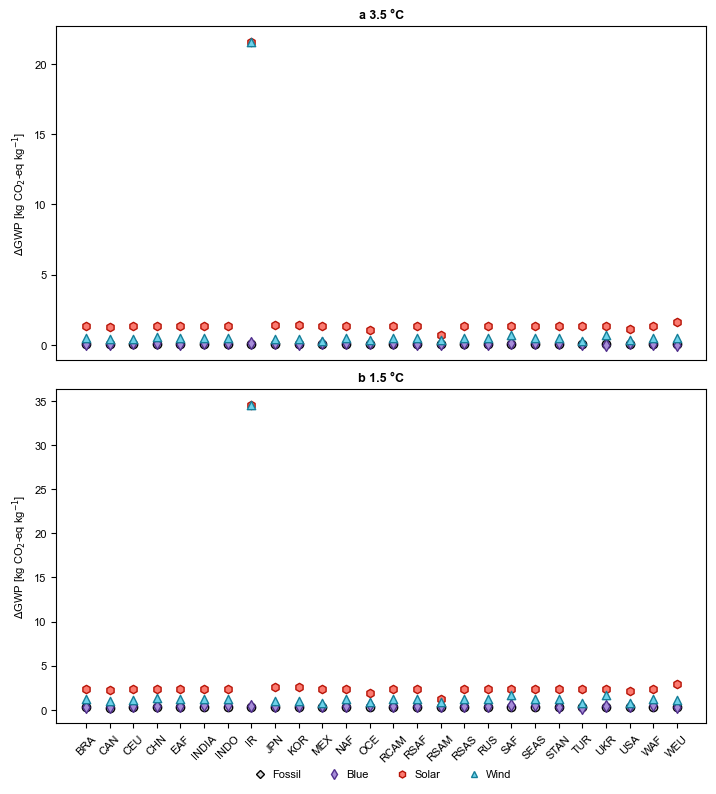

In [69]:
plot('Hydrogen', hydrogenBAURCP6Delta, hydrogenBlueRCP6Delta, hydrogenSolarRCP6Delta, hydrogenWindRCP6Delta, 
     hydrogenBAURCP19Delta, hydrogenBlueRCP19Delta, hydrogenSolarRCP19Delta, hydrogenWindRCP19Delta)

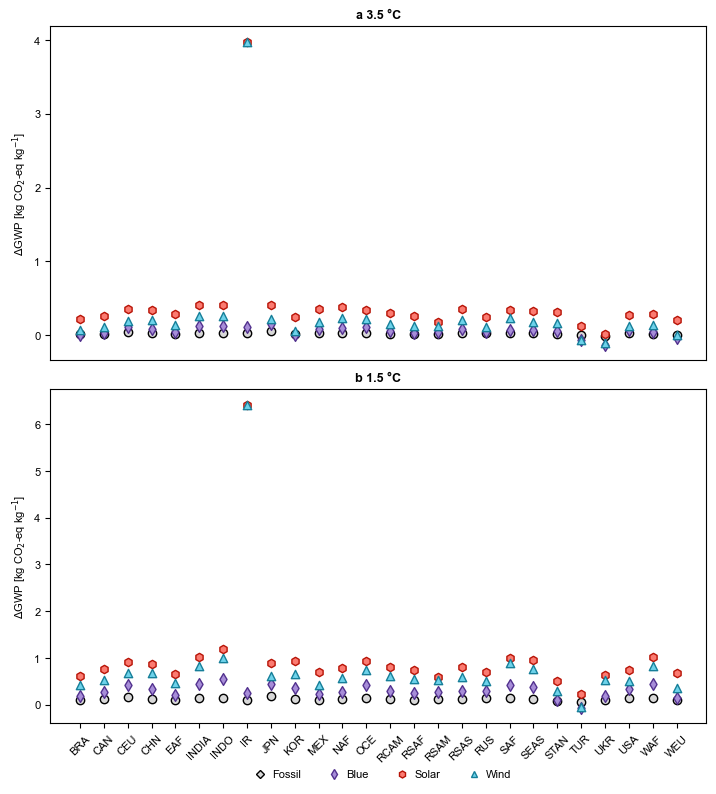

In [70]:
plot('Ammonia', ammoniaBAURCP6Delta, ammoniaBlueRCP6Delta, ammoniaSolarRCP6Delta, ammoniaWindRCP6Delta, 
     ammoniaBAURCP19Delta, ammoniaBlueRCP19Delta, ammoniaSolarRCP19Delta, ammoniaWindRCP19Delta)

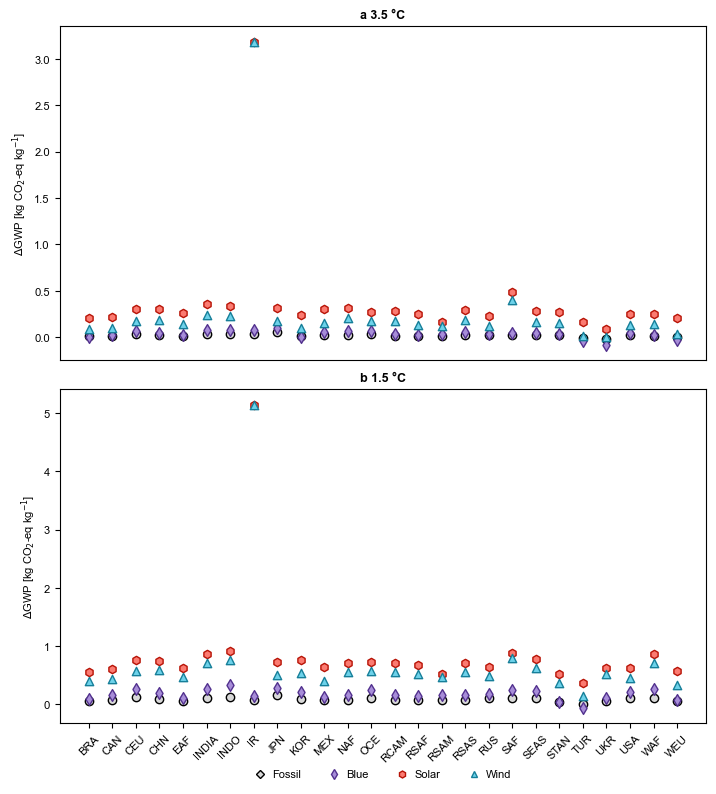

In [71]:
plot('Methanol', methanolBAURCP6Delta, methanolBlueRCP6Delta, methanolSolarRCP6Delta, methanolWindRCP6Delta, 
     methanolBAURCP19Delta, methanolBlueRCP19Delta, methanolSolarRCP19Delta, methanolWindRCP19Delta)

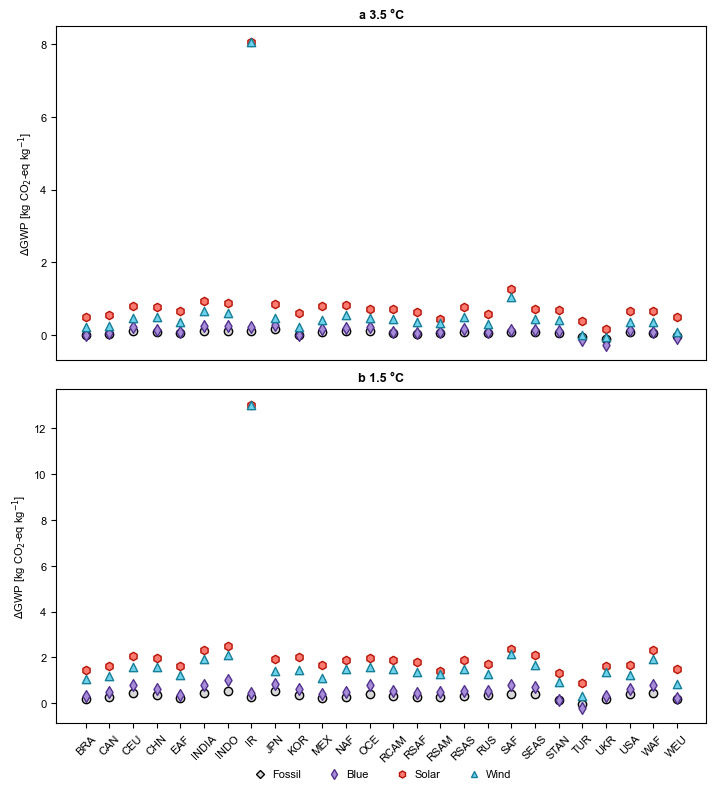

In [72]:
plot('Ethylene', ethyleneBAURCP6Delta, ethyleneBlueRCP6Delta, ethyleneSolarRCP6Delta, ethyleneWindRCP6Delta, 
     ethyleneBAURCP19Delta, ethyleneBlueRCP19Delta, ethyleneSolarRCP19Delta, ethyleneWindRCP19Delta)